<a href="https://colab.research.google.com/drive/1TcQLOxCr_b1xYAycokiRNk13xor4VRRF?usp=sharing" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Week 4_Tugas 2_EDA_BRImo
### Nabila Shinta Luthfia
### 5026231038

In [2]:
# Mengimpor module drive dari google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Mengimpor library pandas untuk membaca dan mengolah data
import pandas as pd

# Menentukan lokasi file CSV di Google Drive
file_path = "/content/drive/MyDrive/brimo_raw_reviews.csv"

# Membaca file CSV dan menyimpannya ke dalam DataFrame
df_brimo = pd.read_csv(file_path)

#  Menampilkan 5 baris pertama untuk melihat isi data
df_brimo.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,daedabb3-8d37-4587-9e52-0a89c025b41d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot susah trnfen juga.. tolong di perbaiki j...,5,0,2.92.1,2026-03-15 13:11:42,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-11-01 10:02:25,2.92.1
1,720f9a74-1b57-4e8d-8fc1-b47710e5b165,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa masuk kocak,5,0,2.95.0,2026-03-15 13:11:38,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-03-15 14:27:14,2.95.0
2,4c7158b6-8729-49e1-aa0b-22b96060ad4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mempermudah transaksi,5,0,2.94.0,2026-03-15 13:10:04,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:26:36,2.94.0
3,ff662000-6c8d-4ab9-9839-bfe68c079787,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0,2.94.0,2026-03-15 13:08:50,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:22:40,2.94.0
4,bd67718b-e62b-47ce-8385-8a40046e1dad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus dan sangat bermanfaat,5,0,2.94.0,2026-03-15 13:08:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:27:05,2.94.0


In [4]:
# Menginstall library yang dibutuhkan untuk analisis data dan visualisasi
!pip install pandas matplotlib seaborn nltk

In [5]:
!pip install seaborn

In [6]:
import pandas as pd # Untuk membaca dan mengolah data
import matplotlib.pyplot as plt # Untuk membuat grafik/plot
import seaborn as sns # Untuk visualisasi data yang lebih menarik
from collections import Counter # Mengimpor Counter untuk menghitung frekuensi data
import nltk # Mengimpor nltk untuk pengolahan teks (Natural Language Processing)
import string # Mengimpor string untuk membantu manipulasi teks (misal hapus tanda baca)

In [7]:
# Mengunduh dataset stopwords dari NLTK
nltk.download('stopwords')

# Mengimpor daftar stopwords dari NLTK
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df_brimo = df_brimo.head(2000)

# Menginstall library Sastrawi untuk stemming bahasa Indonesia
!pip install Sastrawi

import re # Untuk manipulasi teks (regex)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Untuk stemming bahasa Indonesia


# Membuat objek stemmer dan lemmatizer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

#  Membersihkan teks
def clean_text(text):
    # Case lowering
    text = text.lower()

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Stemming
    text = stemmer.stem(text)


# Menerapkan fungsi cleaning ke kolom 'content'
df_brimo['cleaned_review'] = df_brimo['content'].apply(clean_text)

# Menampilkan hasil sebelum dan sesudah cleaning
print(df_brimo[['content', 'cleaned_review']])




                                                content cleaned_review
0     lemot susah trnfen juga.. tolong di perbaiki j...           None
1                                   ga bisa masuk kocak           None
2                                 mempermudah transaksi           None
3          saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳           None
4                           bagus dan sangat bermanfaat           None
...                                                 ...            ...
1995  Brimo kalah sama apk digital yg lain makin par...           None
1996                                             mantap           None
1997  kak saya pengguna baru BRImo,barusan saya biki...           None
1998                         bagus memudahkan transaksi           None
1999                    bagus cepat dan sangat membantu           None

[2000 rows x 2 columns]


In [11]:
# Data Overview
# Mengubah kolom 'at' menjadi format datetime (tanggal & waktu)
df_brimo['at'] = pd.to_datetime(df_brimo['at'])

# Menampilkan informasi dataset (jumlah data, tipe data, dll)
df_brimo.info()

# Menampilkan 5 baris pertama dari dataset
df_brimo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2000 non-null   object        
 1   userName              2000 non-null   object        
 2   userImage             2000 non-null   object        
 3   content               2000 non-null   object        
 4   score                 2000 non-null   int64         
 5   thumbsUpCount         2000 non-null   int64         
 6   reviewCreatedVersion  1619 non-null   object        
 7   at                    2000 non-null   datetime64[ns]
 8   replyContent          1984 non-null   object        
 9   repliedAt             1984 non-null   object        
 10  appVersion            1619 non-null   object        
 11  cleaned_review        0 non-null      object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 187.6+ KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,daedabb3-8d37-4587-9e52-0a89c025b41d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,lemot susah trnfen juga.. tolong di perbaiki j...,5,0,2.92.1,2026-03-15 13:11:42,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-11-01 10:02:25,2.92.1,None
1,720f9a74-1b57-4e8d-8fc1-b47710e5b165,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ga bisa masuk kocak,5,0,2.95.0,2026-03-15 13:11:38,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-03-15 14:27:14,2.95.0,None
2,4c7158b6-8729-49e1-aa0b-22b96060ad4e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mempermudah transaksi,5,0,2.94.0,2026-03-15 13:10:04,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:26:36,2.94.0,None
3,ff662000-6c8d-4ab9-9839-bfe68c079787,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya kasi bintang full ya Mo 🙏😊👍🤗😉☕🥟🥮🍩🍱🤝🫱🫲🤝🥳,5,0,2.94.0,2026-03-15 13:08:50,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:22:40,2.94.0,None
4,bd67718b-e62b-47ce-8385-8a40046e1dad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bagus dan sangat bermanfaat,5,0,2.94.0,2026-03-15 13:08:08,"Hai Sobat BRI, terima kasih atas ulasannya ☺️....",2026-03-15 14:27:05,2.94.0,None


In [12]:
# Missing Values Analysis
# Mengecek jumlah data yang kosong (missing values) di setiap kolom
missing_values = df_brimo.isnull().sum()

# Menampilkan judul output
print("Missing Values Summary:")

# Menampilkan jumlah missing values per kolom
print(missing_values)

Missing Values Summary:
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     381
at                         0
replyContent              16
repliedAt                 16
appVersion               381
cleaned_review          2000
dtype: int64


/tmp/ipykernel_37146/2971741256.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_brimo['score'], palette="viridis")


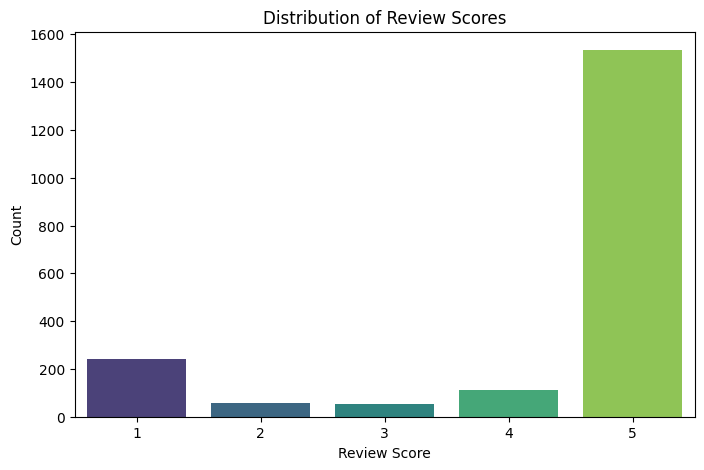

In [13]:
# Review Score Distribution
# Membuat ukuran grafik
plt.figure(figsize=(8,5))

# Membuat grafik countplot untuk distribusi nilai review (score)
sns.countplot(x=df_brimo['score'], palette="viridis")

# Menambahkan judul grafik
plt.title("Distribution of Review Scores")

# Label sumbu X
plt.xlabel("Review Score")

# Label sumbu Y
plt.ylabel("Count")

# Menampilkan grafik
plt.show()

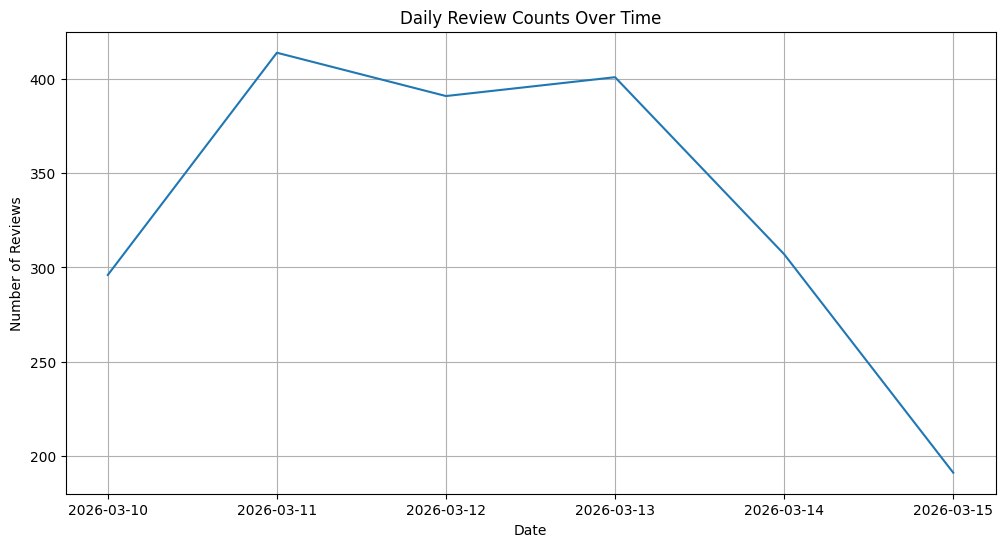

In [14]:
# Review Trends Over Time
# Mengambil tanggal saja dari kolom 'at' (tanpa waktu)
df_brimo['review_date'] = df_brimo['at'].dt.date

# Mengelompokkan data berdasarkan tanggal dan menghitung jumlah review per hari
review_trend = df_brimo.groupby('review_date').size()

# Membuat ukuran grafik
plt.figure(figsize=(12, 6))

# Membuat grafik tren jumlah review per hari
review_trend.plot()

# Menambahkan judul grafik
plt.title("Daily Review Counts Over Time")

# Label sumbu X
plt.xlabel("Date")

# Label sumbu Y
plt.ylabel("Number of Reviews")

# Menampilkan grid pada grafik
plt.grid(True)

# Menampilkan grafik
plt.show()

In [15]:
# Word Frequency Analysis
# Mengambil daftar stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Menggabungkan semua teks review menjadi satu string
all_reviews = " ".join(df_brimo['content'].dropna()).lower()

# Menghapus tanda baca dari teks
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Memecah teks menjadi kata-kata (tokenization)
words = all_reviews.split()

# Menghapus stopwords (kata yang tidak penting)
filtered_words = [word for word in words if word not in stop_words]

# Menghitung frekuensi kemunculan setiap kata
word_counts = Counter(filtered_words)

# Mengambil 20 kata paling sering muncul dan ubah ke DataFrame
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Menampilkan hasil kata yang paling sering muncul
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
         Word  Frequency
0       brimo        310
1    aplikasi        227
2       bagus        201
3       mudah        193
4    membantu        185
5         nya        152
6   transaksi        145
7      mantap        143
8       putih        125
9       cepat        113
10      login        113
11       buka        103
12         ok         92
13      layar         85
14        gak         84
15        bri         76
16         ga         74
17      masuk         73
18         yg         71
19         ya         59
